# CDSE eodata S3

In [1]:
import os
import boto3
import pystac_client
import rioxarray as rxr
from dotenv import load_dotenv, find_dotenv
from rasterio.env import Env
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import xarray as xr

# Finding the S3 keys using pystac

Use a search function to filter the STAC with pystac, sets up a bbox in the Lena Delta Region in Siberia, limits the items per page to 100 to avoid 'out of memory' errors, as well as finding data with less than 20% cloud cover.

In [ ]:
cdse = pystac_client.Client.open('https://stac.dataspace.copernicus.eu/v1')

items = list(cdse.search(
collections=['sentinel-2-l2a'],
bbox=[123.0, 72.0, 126.0, 73.0],
datetime='2023-07-01/2023-08-31',
query = {'eo:cloud_cover': {'lt': 20}},
limit=100
).items())

print(len(items), 'products found')

## Extracts the paths from the list of products and appends these to a 2D array

S3_keys = np.zeros((len(items), len(items[0].assets)))

asset_keys = list(items[0].assets.keys())

for i in range(len(items)):
    for j in range(len(items[i].assets)):
        S3_keys[i][j] = items[i].assets[asset_keys[j]]

print(S3_keys.shape)
        

"""S3_path_B02 = items[1].assets['B02_10m'].href
S3_path_B03 = items[1].assets['B03_10m'].href
S3_path_B04 = items[1].assets['B04_10m'].href

200 products found


TypeError: 'int' object is not iterable

In [59]:
print(len(items[80].assets))

asset_keys = list(items[80].assets.keys())

type(asset_keys[0])

47


str

## Converts the .JP2 band data to a COG

First connects to the CDSE S3 archive using the credentials stored in the .env file. 

The next blocks fix an error relating to a misrouting by GDAL (Geospatial Data Abstraction Library, engine behind rasterio and rioxarray that translates between different formats) to the Amazon AWS endpoint (which requires S3 environment variables to be explicitly configured), as well as an error relating to AWS access keys needing to be managed by boto3.session. 

The bands are then coverted within the custom environment using rioxarray.

In [32]:
from rasterio.session import AWSSession

load_dotenv('/data/dte/crtg2/S3.env')

## Creates a boto3 session with the CDSE credentials stored in the .env file

boto_session = boto3.Session(
    aws_access_key_id=os.getenv('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv('AWS_SECRET_ACCESS_KEY'),)


## Creates an AWS session using rasterio that wraps around the boto3 session and points to the CDSE's S3 endpoint URL

rio_session = AWSSession(
    session=boto_session,
    endpoint_url="https://eodata.dataspace.copernicus.eu")

## 'Lazily' reads the data (just reads metadata and creates a pointer to the file) using the custom session created above 
## and the S3 key (path) pulled from the STAC. The data is then clipped to the AOI and fetched over S3 using .load(), this
## allows it to be accessed outside of the 'with Env():' block where the credentials are held.

with Env(
    session=rio_session,
    AWS_S3_ENDPOINT="eodata.dataspace.copernicus.eu",
    AWS_VIRTUAL_HOSTING="FALSE",
    GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR"):
		band_02 = rxr.open_rasterio(S3_path_B02, mask_and_scale = True)
		band_03 = rxr.open_rasterio(S3_path_B03, mask_and_scale = True)
		band_04 = rxr.open_rasterio(S3_path_B04, mask_and_scale = True)

		band_02_clipped = band_02.rio.clip_box(minx=120.0, miny=72.0, maxx=121.0, maxy=72.2, crs="EPSG:4326").load()
		band_03_clipped = band_03.rio.clip_box(minx=120.0, miny=72.0, maxx=121.0, maxy=72.2, crs="EPSG:4326").load()
		band_04_clipped = band_04.rio.clip_box(minx=120.0, miny=72.0, maxx=121.0, maxy=72.2, crs="EPSG:4326").load()


In [21]:
print(band_04_clipped)

print("Min value:", np.min(band_04_clipped))
print("Max value:", np.max(band_04_clipped))
print("Number of non-NaN pixels:", np.count_nonzero(~np.isnan(band_04_clipped.values)))

selected_item = items[1]
print("Item ID:", selected_item.id)
print("Item Bounding Box [min_lon, min_lat, max_lon, max_lat]:")
print(selected_item.bbox)

<xarray.DataArray (band: 1, y: 2133, x: 976)> Size: 8MB
array([[[1854., 1814., 1811., ..., 2598., 2610., 2450.],
        [1834., 1816., 1818., ..., 2620., 2712., 2686.],
        [1844., 1822., 1838., ..., 2660., 2664., 2698.],
        ...,
        [1512., 1572., 1514., ...,    0.,    0.,    0.],
        [1475., 1540., 1492., ...,    0.,    0.,    0.],
        [1486., 1539., 1523., ...,    0.,    0.,    0.]]],
      shape=(1, 2133, 976), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 17kB 8.012e+06 8.012e+06 ... 7.99e+06 7.99e+06
  * x            (x) float64 8kB 5e+05 5e+05 5e+05 ... 5.097e+05 5.098e+05
    spatial_ref  int64 8B 0
Min value: <xarray.DataArray ()> Size: 4B
array(0., dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
Max value: <xarray.DataArray ()> Size: 4B
array(3880., dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
Number of non-NaN pixels: 2081808
Item ID: S2A_MSIL2A_20230829T042711_N0510_R133_T51XVA_20240821T0

## The .JP2 files are written to COGs 

Took 3.56 seconds per conversion.

In [4]:
band_02.rio.to_raster('B02_cog.tif', driver='COG', compress='DEFLATE')
band_03.rio.to_raster('B03_cog.tif', driver='COG', compress='DEFLATE')
band_04.rio.to_raster('B04_cog.tif', driver='COG', compress='DEFLATE')

Warning 1: HTTP response code on https://eodata.s3.us-east-2.amazonaws.com/Sentinel-2/MSI/L2A_N0500/2023/08/29/S2A_MSIL2A_20230829T042711_N0510_R133_T51XVA_20240821T023236.SAFE/GRANULE/L2A_T51XVA_A042744_20230829T042708/IMG_DATA/R10m/T51XVA_20230829T042711_B02_10m.jp2: 403
Warning 1: HTTP response code on https://eodata.s3.us-east-2.amazonaws.com/Sentinel-2/MSI/L2A_N0500/2023/08/29/S2A_MSIL2A_20230829T042711_N0510_R133_T51XVA_20240821T023236.SAFE/GRANULE/L2A_T51XVA_A042744_20230829T042708/IMG_DATA/R10m/T51XVA_20230829T042711_B02_10m.jp2: 403
Warning 1: HTTP response code on https://eodata.s3.us-east-2.amazonaws.com/Sentinel-2/MSI/L2A_N0500/2023/08/29/S2A_MSIL2A_20230829T042711_N0510_R133_T51XVA_20240821T023236.SAFE/GRANULE/L2A_T51XVA_A042744_20230829T042708/IMG_DATA/R10m/T51XVA_20230829T042711_B02_10m.jp2: 403
Warning 1: HTTP response code on https://eodata.s3.us-east-2.amazonaws.com/Sentinel-2/MSI/L2A_N0500/2023/08/29/S2A_MSIL2A_20230829T042711_N0510_R133_T51XVA_20240821T023236.SAFE/G

## Clips to the AOI using rioxarray 

Defines the co-ordinate reference system as EPSG: 4326 which is in degrees (lon/lat). The function automatically converts the provided co-ordinates to the UTM (Universal Transverse Mercator) system used by the Sentinel-2 .jp2 data, before using them to clip.

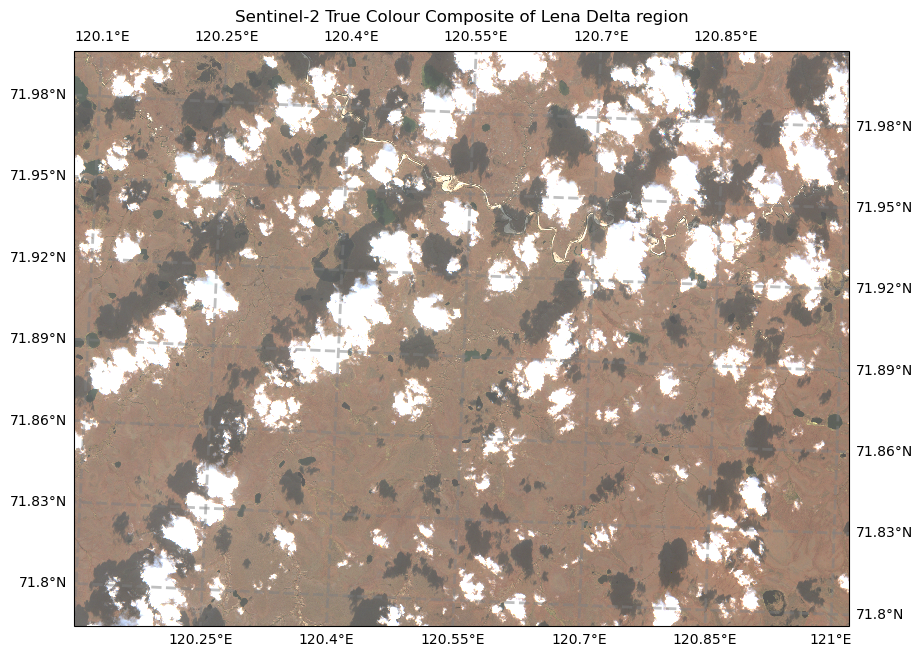

In [40]:
epsg_code = band_04_clipped.rio.crs.to_epsg()
utm_crs = ccrs.epsg(epsg_code)

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": utm_crs})

rgb = xr.concat([band_04_clipped, band_03_clipped, band_02_clipped], dim="band")

rgb_scaled = (rgb / 3000.0).clip(0, 1)

rgb_scaled.plot.imshow(col_wrap=None)

#band_04_clipped.squeeze().plot.imshow(ax=ax, cmap="Reds", robust=True)  ## Squeeze removes the extra 'band' dimension (size 1)

ax.gridlines(draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--')


plt.title("Sentinel-2 True Colour Composite of Lena Delta region")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [90]:
print("Shape:", rgb_float.shape)
print("Min value:", np.nanmin(rgb_float))
print("Max value:", np.nanmax(rgb_float))
print("2nd Percentile (p2):", np.nanpercentile(rgb_float, 2))
print("98th Percentile (p98):", np.nanpercentile(rgb_float, 98))

Shape: (3, 2133, 976)
Min value: 0.0
Max value: 65510.0
2nd Percentile (p2): 0.0
98th Percentile (p98): 0.0
